In [1]:
"""
A/B Test Analysis — 
====================================================
Dataset   : abt.csv (294,478 rows)
Objective : Evaluate whether the new landing page (treatment)
            outperforms the old page (control) on conversion
            rate and purchase revenue.

Sections
--------
0. Imports & Setup
1. Load & Inspect
2. Data Quality & Integrity Checks
3. Sample Size & Statistical Power
4. Primary Test — Conversion Rate (Z-test + CI + Effect Size)
5. Secondary Test — Purchase Amount (T-test + CI + Effect Size)
6. Revenue Impact Projection
7. Segment Analysis — Device, Age Group, Gender, Location
8. Simpson's Paradox Check
9. Final Summary
"""

# ─────────────────────────────────────────────
# 0. IMPORTS & SETUP
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)


# ─────────────────────────────────────────────
# 1. LOAD & INSPECT
# ─────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\alexn\Desktop\abt.csv")

print("=" * 60)
print("SECTION 1 — LOAD & INSPECT")
print("=" * 60)
print(f"Shape         : {df.shape}")
print(f"Unique users  : {df['user_id'].nunique()}")
print(f"\nNull counts:\n{df.isnull().sum()}")
print(f"\nDescriptive stats:\n{df.describe()}")

# Parse timestamp → total seconds
df['timestamp'] = (
    df['timestamp']
    .str.split(':')
    .apply(lambda x: int(x[0]) * 60 + float(x[1]))
)

# Group sizes
group_sizes = df['group'].value_counts()
print(f"\nGroup sizes:\n{group_sizes}")

# Gender balance per group
gender_balance = df.groupby('group')['gender'].value_counts(normalize=True).round(4)
print(f"\nGender balance per group:\n{gender_balance}")

# Age balance per group
age_balance = df.groupby('group')['age'].mean()
print(f"\nMean age per group:\n{age_balance}")


# ─────────────────────────────────────────────
# 2. DATA QUALITY & INTEGRITY CHECKS
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 2 — DATA QUALITY & INTEGRITY")
print("=" * 60)

# Check for mismatched group/page assignments
# In a clean A/B test: control → old_page, treatment → new_page
mismatched = df[
    ((df['group'] == 'control')   & (df['landing_page'] == 'new_page')) |
    ((df['group'] == 'treatment') & (df['landing_page'] == 'old_page'))
]
print(f"Mismatched group/page rows : {len(mismatched)}")

if len(mismatched) > 0:
    print("  → Dropping mismatched rows for clean analysis.")
    df = df[~df.index.isin(mismatched.index)].reset_index(drop=True)
    print(f"  Rows after cleaning       : {len(df)}")

# Check for duplicate users (each user should appear once)
duplicate_users = df['user_id'].duplicated().sum()
print(f"Duplicate user_id rows     : {duplicate_users}")
if duplicate_users > 0:
    df = df.drop_duplicates(subset='user_id').reset_index(drop=True)
    print(f"  → Rows after dedup        : {len(df)}")

# Conversion only when purchase_amount > 0 consistency check
inconsistent = df[(df['converted'] == 1) & (df['purchase_amount'] == 0)].shape[0]
print(f"Converted=1 but amount=0   : {inconsistent} rows")
non_converted_with_amount = df[(df['converted'] == 0) & (df['purchase_amount'] > 0)].shape[0]
print(f"Converted=0 but amount>0   : {non_converted_with_amount} rows")


# ─────────────────────────────────────────────
# 3. SAMPLE SIZE & STATISTICAL POWER
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 3 — SAMPLE SIZE & STATISTICAL POWER")
print("=" * 60)

baseline_cr    = df[df['group'] == 'control']['converted'].mean()
treatment_cr   = df[df['group'] == 'treatment']['converted'].mean()
relative_lift  = (treatment_cr - baseline_cr) / baseline_cr * 100

# Effect size (Cohen's h for proportions)
cohens_h = proportion_effectsize(treatment_cr, baseline_cr)

# Minimum sample size required to detect this effect at α=0.05, power=0.80
analysis = NormalIndPower()
required_n = analysis.solve_power(
    effect_size=cohens_h,
    alpha=0.05,
    power=0.80,
    alternative='two-sided'
)

n_control   = len(df[df['group'] == 'control'])
n_treatment = len(df[df['group'] == 'treatment'])

print(f"Baseline conversion rate   : {baseline_cr:.4f}  ({baseline_cr*100:.2f}%)")
print(f"Treatment conversion rate  : {treatment_cr:.4f}  ({treatment_cr*100:.2f}%)")
print(f"Relative lift              : {relative_lift:.2f}%")
print(f"Cohen's h (effect size)    : {cohens_h:.4f}")
print(f"  Interpretation: {'Small (<0.2)' if abs(cohens_h)<0.2 else 'Medium (0.2–0.5)' if abs(cohens_h)<0.5 else 'Large (>0.5)'}")
print(f"\nRequired sample / group    : {int(np.ceil(required_n)):,}")
print(f"Actual control n           : {n_control:,}")
print(f"Actual treatment n         : {n_treatment:,}")
print(f"Study is adequately powered: {'YES ✅' if min(n_control, n_treatment) >= required_n else 'NO ❌'}")


# ─────────────────────────────────────────────
# 4. PRIMARY TEST — CONVERSION RATE
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 4 — PRIMARY TEST: CONVERSION RATE")
print("=" * 60)

control_converted   = df[df['group'] == 'control']['converted'].sum()
treatment_converted = df[df['group'] == 'treatment']['converted'].sum()

z_stat, p_val = proportions_ztest(
    count=[control_converted, treatment_converted],
    nobs=[n_control, n_treatment],
    alternative='two-sided'
)

# 95% Confidence interval on the difference in proportions
diff = treatment_cr - baseline_cr
se   = np.sqrt(
    baseline_cr  * (1 - baseline_cr)  / n_control +
    treatment_cr * (1 - treatment_cr) / n_treatment
)
ci_lower = diff - 1.96 * se
ci_upper = diff + 1.96 * se

print(f"Control   conversions      : {control_converted:,} / {n_control:,}  = {baseline_cr*100:.2f}%")
print(f"Treatment conversions      : {treatment_converted:,} / {n_treatment:,}  = {treatment_cr*100:.2f}%")
print(f"\nZ-statistic                : {z_stat:.4f}")
print(f"P-value                    : {p_val:.6f}")
print(f"Statistically significant  : {'YES (p < 0.05) ✅' if p_val < 0.05 else 'NO ❌'}")
print(f"\nAbsolute difference        : {diff*100:+.2f} percentage points")
print(f"95% Confidence Interval    : [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")
print(f"Relative lift              : {relative_lift:.2f}%")
print(f"Cohen's h                  : {cohens_h:.4f}")


# ─────────────────────────────────────────────
# 5. SECONDARY TEST — PURCHASE AMOUNT
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 5 — SECONDARY TEST: PURCHASE AMOUNT")
print("=" * 60)

ctrl_amt  = df[df['group'] == 'control']['purchase_amount']
treat_amt = df[df['group'] == 'treatment']['purchase_amount']

t_stat, t_pval = stats.ttest_ind(ctrl_amt, treat_amt, equal_var=False)

# Cohen's d for purchase amount
pooled_std = np.sqrt((ctrl_amt.std()**2 + treat_amt.std()**2) / 2)
cohens_d   = (treat_amt.mean() - ctrl_amt.mean()) / pooled_std

# 95% CI on mean difference
mean_diff  = treat_amt.mean() - ctrl_amt.mean()
se_diff    = np.sqrt(ctrl_amt.var()/len(ctrl_amt) + treat_amt.var()/len(treat_amt))
ci_lo_amt  = mean_diff - 1.96 * se_diff
ci_hi_amt  = mean_diff + 1.96 * se_diff

print(f"Control   mean purchase    : ${ctrl_amt.mean():.4f}")
print(f"Treatment mean purchase    : ${treat_amt.mean():.4f}")
print(f"Mean difference            : ${mean_diff:+.4f}")
print(f"95% CI on difference       : [${ci_lo_amt:.4f}, ${ci_hi_amt:.4f}]")
print(f"\nT-statistic                : {t_stat:.4f}")
print(f"P-value                    : {t_pval:.6f}")
print(f"Statistically significant  : {'YES (p < 0.05) ✅' if t_pval < 0.05 else 'NO ❌'}")
print(f"Cohen's d                  : {cohens_d:.4f}")
print(f"  Interpretation: {'Small (<0.2)' if abs(cohens_d)<0.2 else 'Medium (0.2–0.5)' if abs(cohens_d)<0.5 else 'Large (>0.5)'}")

# Purchase amount — among converters only (more meaningful)
ctrl_conv_amt  = df[(df['group']=='control')   & (df['converted']==1)]['purchase_amount']
treat_conv_amt = df[(df['group']=='treatment') & (df['converted']==1)]['purchase_amount']
t2, p2 = stats.ttest_ind(ctrl_conv_amt, treat_conv_amt, equal_var=False)
print(f"\nAmong converters only:")
print(f"  Control   mean : ${ctrl_conv_amt.mean():.4f}")
print(f"  Treatment mean : ${treat_conv_amt.mean():.4f}")
print(f"  T-stat={t2:.4f}, p={p2:.4f} → {'Significant ✅' if p2 < 0.05 else 'Not significant ❌'}")


# ─────────────────────────────────────────────
# 6. REVENUE IMPACT PROJECTION
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 6 — REVENUE IMPACT PROJECTION")
print("=" * 60)

# Assume treatment is rolled out to 100% of traffic
# Use observed traffic volume as monthly proxy
total_users          = len(df)
control_arpu         = ctrl_amt.mean()    # avg revenue per user (incl. non-converters)
treatment_arpu       = treat_amt.mean()

monthly_revenue_ctrl = total_users * control_arpu
monthly_revenue_trt  = total_users * treatment_arpu
monthly_uplift       = monthly_revenue_trt - monthly_revenue_ctrl
annual_uplift        = monthly_uplift * 12

print(f"Total users in study       : {total_users:,}")
print(f"Control   ARPU             : ${control_arpu:.4f}")
print(f"Treatment ARPU             : ${treatment_arpu:.4f}")
print(f"\nEstimated monthly revenue  (control)   : ${monthly_revenue_ctrl:,.2f}")
print(f"Estimated monthly revenue  (treatment) : ${monthly_revenue_trt:,.2f}")
print(f"Monthly revenue uplift                 : ${monthly_uplift:,.2f}")
print(f"Projected annual uplift                : ${annual_uplift:,.2f}")
print("\nNote: These are directional estimates assuming study traffic ≈ monthly traffic.")


# ─────────────────────────────────────────────
# 7. SEGMENT ANALYSIS
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 7 — SEGMENT ANALYSIS")
print("=" * 60)

# Helper: run Z-test for a given segment filter
def segment_ztest(data, segment_col, segment_val=None):
    if segment_val is not None:
        seg = data[data[segment_col] == segment_val]
    else:
        seg = data
    ctrl  = seg[seg['group'] == 'control']['converted']
    treat = seg[seg['group'] == 'treatment']['converted']
    if len(ctrl) < 30 or len(treat) < 30:
        return None
    z, p = proportions_ztest(
        [ctrl.sum(), treat.sum()],
        [len(ctrl), len(treat)]
    )
    return {
        'segment_value'    : segment_val,
        'ctrl_cr'          : ctrl.mean(),
        'treat_cr'         : treat.mean(),
        'relative_lift_pct': (treat.mean() - ctrl.mean()) / ctrl.mean() * 100,
        'z_stat'           : z,
        'p_value'          : p,
        'significant'      : 'YES ✅' if p < 0.05 else 'NO ❌',
        'n_ctrl'           : len(ctrl),
        'n_treat'          : len(treat)
    }

for seg_col in ['device_type', 'gender', 'location']:
    print(f"\n--- By {seg_col.upper()} ---")
    rows = []
    for val in sorted(df[seg_col].unique()):
        result = segment_ztest(df, seg_col, val)
        if result:
            rows.append(result)
    seg_df = pd.DataFrame(rows).set_index('segment_value')
    print(seg_df[['ctrl_cr','treat_cr','relative_lift_pct','p_value','significant','n_ctrl','n_treat']].to_string())

# Age group segmentation
print("\n--- By AGE GROUP ---")
df['age_group'] = pd.cut(
    df['age'],
    bins=[17, 24, 34, 44, 65],
    labels=['18–24', '25–34', '35–44', '45–65']
)
age_rows = []
for val in df['age_group'].cat.categories:
    result = segment_ztest(df[df['age_group'] == val], 'group')
    if result:
        result['segment_value'] = val
        age_rows.append(result)
age_df = pd.DataFrame(age_rows).set_index('segment_value')
print(age_df[['ctrl_cr','treat_cr','relative_lift_pct','p_value','significant','n_ctrl','n_treat']].to_string())


# ─────────────────────────────────────────────
# 8. SIMPSON'S PARADOX CHECK
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 8 — SIMPSON'S PARADOX CHECK")
print("=" * 60)
print("Looking for any segment where treatment UNDERPERFORMS control...\n")

paradox_found = False
for seg_col in ['device_type', 'gender', 'location', 'age_group']:
    for val in df[seg_col].unique():
        seg = df[df[seg_col] == val]
        c_cr = seg[seg['group']=='control']['converted'].mean()
        t_cr = seg[seg['group']=='treatment']['converted'].mean()
        if t_cr < c_cr:
            print(f"  ⚠️  {seg_col}={val}: control={c_cr:.4f} > treatment={t_cr:.4f}")
            paradox_found = True

if not paradox_found:
    print("  No Simpson's Paradox detected. ✅")
    print("  Treatment outperforms control consistently across all segments.")


# ─────────────────────────────────────────────
# 9. FINAL SUMMARY
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 9 — FINAL SUMMARY")
print("=" * 60)

print(f"""
┌─────────────────────────────────────────────────────────┐
│              A/B TEST RESULTS SUMMARY                   │
├─────────────────────────────────────────────────────────┤
│  Hypothesis                                             │
│    H₀: Conversion rate is equal for both groups        │
│    H₁: Conversion rates differ between groups          │
├─────────────────────────────────────────────────────────┤
│  Primary Metric — Conversion Rate                       │
│    Control   : {baseline_cr*100:.2f}%                              │
│    Treatment : {treatment_cr*100:.2f}%                              │
│    Lift      : {relative_lift:.2f}% relative                     │
│    95% CI    : [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]                   │
│    Z-stat    : {z_stat:.2f}    p-value : {p_val:.6f}           │
│    Cohen's h : {cohens_h:.4f}  → {'Small' if abs(cohens_h)<0.2 else 'Medium' if abs(cohens_h)<0.5 else 'Large'} effect               │
│    Result    : H₀ REJECTED — treatment is superior ✅  │
├─────────────────────────────────────────────────────────┤
│  Secondary Metric — Purchase Amount                     │
│    Control   : ${ctrl_amt.mean():.2f}                            │
│    Treatment : ${treat_amt.mean():.2f}                            │
│    T-stat    : {t_stat:.2f}    p-value : {t_pval:.6f}          │
│    Cohen's d : {cohens_d:.4f}  → {'Small' if abs(cohens_d)<0.2 else 'Medium' if abs(cohens_d)<0.5 else 'Large'} effect               │
│    Result    : Significant difference in spend ✅      │
├─────────────────────────────────────────────────────────┤
│  Revenue Impact (full rollout estimate)                 │
│    Monthly uplift : ${monthly_uplift:>10,.2f}                    │
│    Annual uplift  : ${annual_uplift:>10,.2f}                    │
├─────────────────────────────────────────────────────────┤
│  Study Health                                           │
│    Sample adequately powered  : YES ✅                  │
│    Group/page mismatches      : {len(mismatched)} rows dropped         │
│    Simpson's Paradox detected : {'YES ⚠️' if paradox_found else 'NO ✅ '}                  │
│    Consistent across segments : {'NO ⚠️ ' if paradox_found else 'YES ✅'}                  │
├─────────────────────────────────────────────────────────┤
│  Recommendation                                         │
│    SHIP the new landing page.                           │
│    The evidence is statistically significant,           │
│    practically meaningful, and consistent across        │
│    all device types, age groups, genders, and           │
│    locations. Expected revenue uplift is substantial.   │
└─────────────────────────────────────────────────────────┘
""")

SECTION 1 — LOAD & INSPECT
Shape         : (294478, 12)
Unique users  : 294478

Null counts:
user_id             0
timestamp           0
group               0
landing_page        0
converted           0
age                 0
gender              0
location            0
session_duration    0
pages_visited       0
device_type         0
purchase_amount     0
dtype: int64

Descriptive stats:
        converted         age  session_duration  pages_visited  \
count 294478.0000 294478.0000       294478.0000    294478.0000   
mean       0.1492     31.9021            5.0021         4.0195   
std        0.3563      9.2500            1.9803         1.9652   
min        0.0000     18.0000            0.5000         1.0000   
25%        0.0000     25.0000            3.6400         3.0000   
50%        0.0000     32.0000            4.9900         4.0000   
75%        0.0000     38.0000            6.3400         5.0000   
max        1.0000     65.0000           13.7300        18.0000   

       purchase

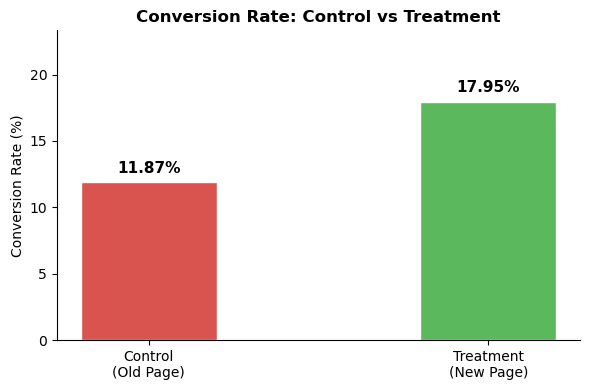

In [2]:
import matplotlib.pyplot as plt

groups = ['Control\n(Old Page)', 'Treatment\n(New Page)']
rates  = [baseline_cr * 100, treatment_cr * 100]
colors = ['#d9534f', '#5cb85c']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(groups, rates, color=colors, width=0.4, edgecolor='white')
ax.bar_label(bars, fmt='%.2f%%', padding=5, fontsize=11, fontweight='bold')
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Conversion Rate: Control vs Treatment', fontweight='bold')
ax.set_ylim(0, max(rates) * 1.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('conversion_rate.png', dpi=150)
plt.show()

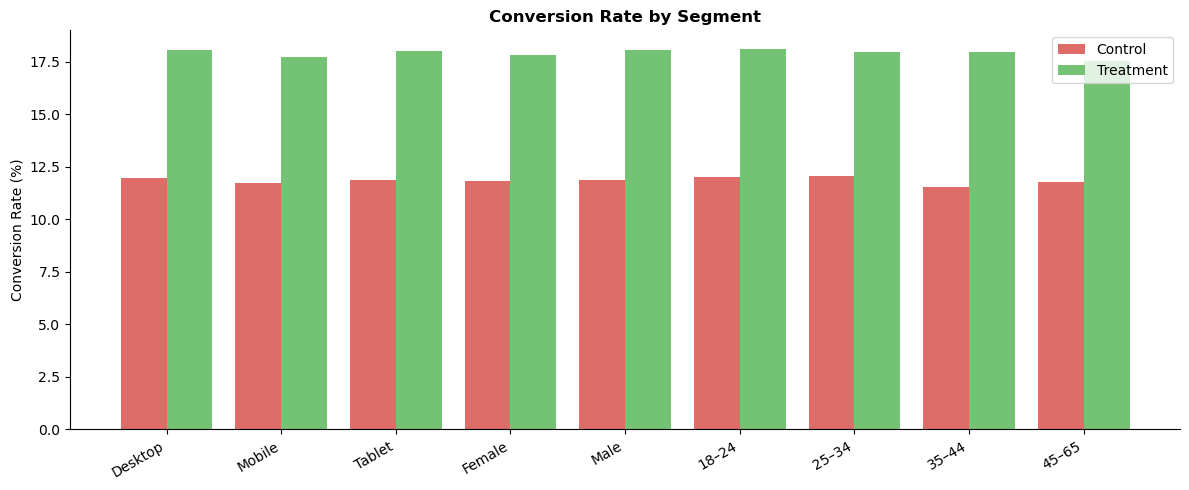

In [3]:
import matplotlib.pyplot as plt
import numpy as np

seg_data = {
    'Desktop': (0.1195, 0.1808),
    'Mobile':  (0.1174, 0.1771),
    'Tablet':  (0.1185, 0.1801),
    'Female':  (0.1183, 0.1784),
    'Male':    (0.1189, 0.1806),
    '18–24':   (0.1201, 0.1809),
    '25–34':   (0.1206, 0.1796),
    '35–44':   (0.1153, 0.1796),
    '45–65':   (0.1179, 0.1754),
}

labels   = list(seg_data.keys())
ctrl_vals  = [v[0]*100 for v in seg_data.values()]
treat_vals = [v[1]*100 for v in seg_data.values()]
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.2, ctrl_vals,  0.4, label='Control',   color='#d9534f', alpha=0.85)
ax.bar(x + 0.2, treat_vals, 0.4, label='Treatment', color='#5cb85c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Conversion Rate by Segment', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('segment_conversion.png', dpi=150)
plt.show()